
PARKINSON'S DISEASE DETECTION
## Phát hiện bệnh Parkinson từ hình vẽ xoắn ốc

**Dataset:** https://www.kaggle.com/datasets/kmader/parkinsons-drawings  
**Models:** VGG19, InceptionV3, ResNet50, DenseNet169  
**Output:** Training results + Test trên ảnh

---
## 📦 BƯỚC 1: SETUP & MOUNT GOOGLE DRIVE

In [ ]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG19, InceptionV3, ResNet50, DenseNet169
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

print(" Libraries imported!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

 Libraries imported!
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def plot_training_history(history, model_name):
    """
    Vẽ biểu đồ Accuracy và Loss
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Plot Loss
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Plot saved: {model_name}_training_history.png\n")


def evaluate_model(model, model_name):
    """
    Đánh giá model và vẽ Confusion Matrix
    """
    # Reset test generator
    test_generator.reset()

    # Predictions
    predictions = model.predict(test_generator, verbose=0)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = test_generator.classes

    # Calculate metrics
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)

    # Classification Report
    print(f"\n📊 CLASSIFICATION REPORT - {model_name}")
    print("="*60)
    target_names = ['Healthy', 'Parkinson']
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 14, 'weight': 'bold'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Confusion Matrix saved: {model_name}_confusion_matrix.png")

    # Return results
    return {
        'test_acc': test_acc,
        'test_loss': test_loss,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred
    }

print("✅ Plotting and evaluation functions defined!")

✅ Plotting and evaluation functions defined!


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("\n Google Drive mounted!")

Mounted at /content/drive

 Google Drive mounted!


In [ ]:


DATASET_PATH = '/content/drive/MyDrive/Parkinsons/drawings/spiral'

# Check dataset structure
print("📂 Checking dataset structure...\n")

train_path = os.path.join(DATASET_PATH, 'training')
test_path = os.path.join(DATASET_PATH, 'testing')

if os.path.exists(train_path):
    print(f"✅ Training path found: {train_path}")
    train_healthy = len(os.listdir(os.path.join(train_path, 'healthy')))
    train_parkinson = len(os.listdir(os.path.join(train_path, 'parkinson')))
    print(f"   - Healthy: {train_healthy} images")
    print(f"   - Parkinson: {train_parkinson} images")
else:
    print("❌ Training path NOT found! Please check DATASET_PATH")

if os.path.exists(test_path):
    print(f"\n✅ Testing path found: {test_path}")
    test_healthy = len(os.listdir(os.path.join(test_path, 'healthy')))
    test_parkinson = len(os.listdir(os.path.join(test_path, 'parkinson')))
    print(f"   - Healthy: {test_healthy} images")
    print(f"   - Parkinson: {test_parkinson} images")
else:
    print("❌ Testing path NOT found! Please check DATASET_PATH")

📂 Checking dataset structure...

✅ Training path found: /content/drive/MyDrive/Parkinsons/drawings/spiral/training
   - Healthy: 36 images
   - Parkinson: 36 images

✅ Testing path found: /content/drive/MyDrive/Parkinsons/drawings/spiral/testing
   - Healthy: 15 images
   - Parkinson: 15 images


---
## 📊 BƯỚC 2: CHUẨN BỊ DATA

In [ ]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0001

print(" Configuration:")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")

 Configuration:
   Image size: 224x224
   Batch size: 16
   Epochs: 50
   Learning rate: 0.0001


In [ ]:
# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# No augmentation for testing
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")

✅ Data generators created!


In [ ]:
# Load data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n✅ Data loaded successfully!")
print(f"   Class indices: {train_generator.class_indices}")

Found 72 images belonging to 2 classes.
Found 30 images belonging to 2 classes.

✅ Data loaded successfully!
   Class indices: {'healthy': 0, 'parkinson': 1}


---
## 🏗️ BƯỚC 3: BUILD MODELS

In [ ]:
# Helper function to create model
def create_model(base_model, model_name):
    """
    Tạo model với Transfer Learning
    """
    # Freeze base model
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    # Create full model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print(f"\n✅ {model_name} created!")
    print(f"   Total params: {model.count_params():,}")
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"   Trainable params: {trainable_params:,}")

    return model

print("✅ Helper function defined!")

✅ Helper function defined!


In [ ]:
# Callbacks
def get_callbacks(model_name):
    """
    Tạo callbacks cho training
    """
    lr_reducer = ReduceLROnPlateau(
        monitor='val_loss',
        factor=np.sqrt(0.1),
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=f'{model_name}_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    return [lr_reducer, early_stop, checkpoint]

print("✅ Callback function defined!")

✅ Callback function defined!


---
## 🎯 BƯỚC 4: TRAIN MODELS

In [ ]:
# Dictionary to store results
results = {}

print("🚀 Starting training process...\n")
print("=" * 60)

🚀 Starting training process...



### 4.1. VGG19


📌 TRAINING MODEL 1/4: VGG19

✅ VGG19 created!
   Total params: 20,155,969
   Trainable params: 131,585
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.4826 - loss: 0.7835
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to VGG19_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4786 - loss: 0.7822 - val_accuracy: 0.5000 - val_loss: 0.6830 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.4952 - loss: 0.7345
Epoch 2: val_accuracy improved from 0.50000 to 0.53333, saving model to VGG19_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 566ms/step - accuracy: 0.5030 - loss: 0.7294 - val_accuracy: 0.5333 - val_loss: 0.6697 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.5531 - loss: 0.7101
Epoch 3: val_accuracy improved from 0.53333 to 0.86667, saving model to VGG19_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 584ms/step - accuracy: 0.5582 - loss: 0.7045 - val_accuracy: 0.8667 - val_loss: 0.6607 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.4668 - loss: 0.7592
Epoch 4: val_accuracy did not improve from 0.86667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 0.4746 - loss: 0.7549 - val_accuracy: 0.8333 - val_loss: 0.6527 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4444 - loss: 0.7240
Epoch 5: val_accuracy did not improve from 0.86667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - accuracy: 0.4444 - loss: 0.7257 - val_accuracy: 0.8667 - val_loss: 0.6450 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.5682 - loss: 0.6540
Epoch 6: val_accuracy did not improve from 0.86667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.5614 - loss: 0.6595 - val_accuracy: 0.8667 - val_loss: 0.6364 - learning_rate: 1.0000e-04
Epoch 7/50
5/5 ━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 0.5495 - loss: 0.6446 - val_accuracy: 0.9000 - val_loss: 0.6286 - learning_rate: 1.0000e-04
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5139 - loss: 0.7109
Epoch 8: val_accuracy did not improve from 0.90000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 0.5162 - loss: 0.7121 - val_accuracy: 0.9000 - val_loss: 0.6216 - learning_rate: 1.0000e-04
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.6585 - loss: 0.6644
Epoch 9: val_accuracy did not improve from 0.90000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 525ms/step - accuracy: 0.6506 - loss: 0.6656 - val_accuracy: 0.8333 - val_loss: 0.6141 - learning_rate: 1.0000e-04
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.5531 - loss: 0.7074
Epoch 10: val_accuracy did not improve from 0.90000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 567ms/step - accuracy: 0.5443 - loss: 0.7106 - val_accuracy: 0.9000 - val_loss: 0.6083 - learning_rate: 1.0000e-04
Epoch 11/50
5/5 ━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 567ms/step - accuracy: 0.7032 - loss: 0.5929 - val_accuracy: 0.9333 - val_loss: 0.5903 - learning_rate: 1.0000e-04
Epoch 14/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6277 - loss: 0.6451
Epoch 14: val_accuracy did not improve from 0.93333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 459ms/step - accuracy: 0.6203 - loss: 0.6513 - val_accuracy: 0.8667 - val_loss: 0.5845 - learning_rate: 1.0000e-04
Epoch 15/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7615 - loss: 0.5582
Epoch 15: val_accuracy did not improve from 0.93333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step - accuracy: 0.7595 - loss: 0.5567 - val_accuracy: 0.8333 - val_loss: 0.5788 - learning_rate: 1.0000e-04
Epoch 16/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.5938 - loss: 0.6522
Epoch 16: val_accuracy did not improve from 0.93333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 711ms/step - accuracy: 0.5967 - loss: 0.6482 - val_accuracy: 0.8333 - val_loss: 0.5739 - learning_rate: 1.0000e-04
Epoch 17/50
5/5 ━

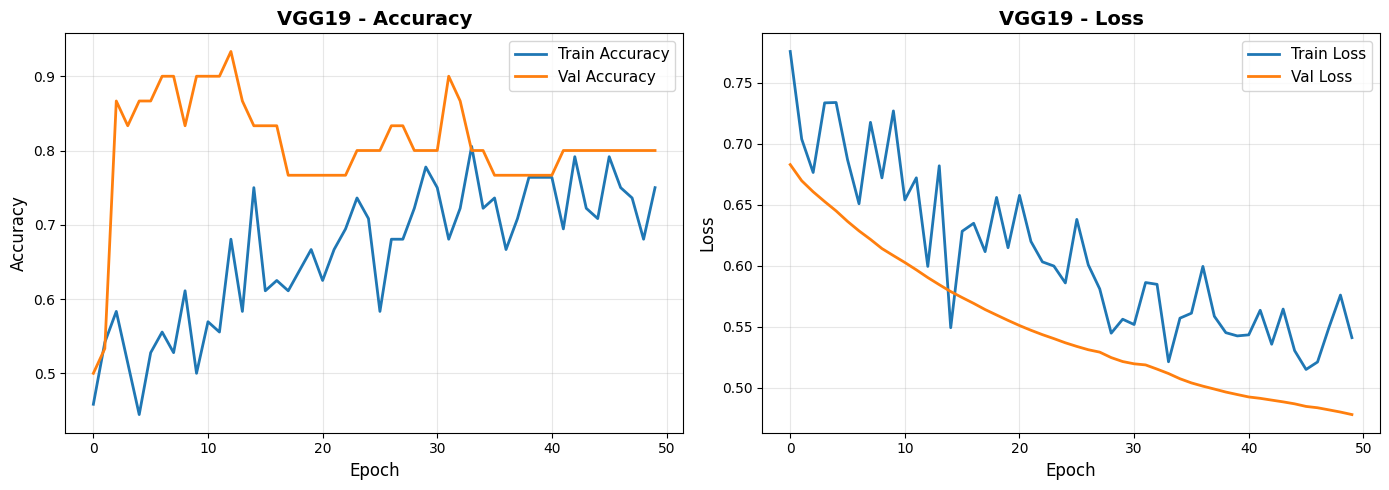

✅ Plot saved: VGG19_training_history.png


📊 CLASSIFICATION REPORT - VGG19
              precision    recall  f1-score   support

     Healthy     0.7368    0.9333    0.8235        15
   Parkinson     0.9091    0.6667    0.7692        15

    accuracy                         0.8000        30
   macro avg     0.8230    0.8000    0.7964        30
weighted avg     0.8230    0.8000    0.7964        30



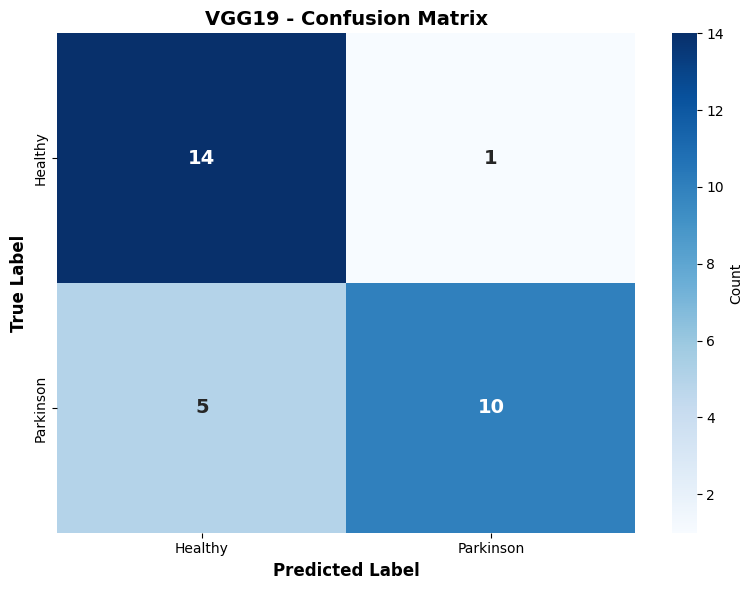

✅ Confusion Matrix saved: VGG19_confusion_matrix.png

✅ VGG19 TRAINING COMPLETE!
   Test Accuracy: 80.00%
   Test Loss: 0.4780


In [ ]:
print("\n" + "="*60)
print("📌 TRAINING MODEL 1/4: VGG19")
print("="*60)

# Create model
base_vgg = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
model_vgg = create_model(base_vgg, 'VGG19')

# Train
history_vgg = model_vgg.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks('VGG19'),
    verbose=1
)

# Plot training history
plot_training_history(history_vgg, 'VGG19')

# Evaluate and get results
eval_results_vgg = evaluate_model(model_vgg, 'VGG19')

# Store results
results['VGG19'] = {
    'history': history_vgg,
    'test_acc': eval_results_vgg['test_acc'],
    'test_loss': eval_results_vgg['test_loss'],
    'model': model_vgg,
    'eval': eval_results_vgg
}

print(f"\n{'='*60}")
print(f"✅ VGG19 TRAINING COMPLETE!")
print(f"   Test Accuracy: {eval_results_vgg['test_acc']*100:.2f}%")
print(f"   Test Loss: {eval_results_vgg['test_loss']:.4f}")
print(f"{'='*60}")

### 4.2. InceptionV3


📌 TRAINING MODEL 2/4: InceptionV3

✅ InceptionV3 created!
   Total params: 22,327,585
   Trainable params: 524,801
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5487 - loss: 0.7584
Epoch 1: val_accuracy improved from -inf to 0.70000, saving model to InceptionV3_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.5382 - loss: 0.7740 - val_accuracy: 0.7000 - val_loss: 0.6393 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.5792 - loss: 0.6975
Epoch 2: val_accuracy improved from 0.70000 to 0.76667, saving model to InceptionV3_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 688ms/step - accuracy: 0.5660 - loss: 0.7083 - val_accuracy: 0.7667 - val_loss: 0.5882 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6865 - loss: 0.6360
Epoch 3: val_accuracy did not improve from 0.76667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 532ms/step - accuracy: 0.6901 - loss: 0.6336 - val_accuracy: 0.7667 - val_loss: 0.5444 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5698 - loss: 0.6586
Epoch 4: val_accuracy did not improve from 0.76667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step - accuracy: 0.5813 - loss: 0.6524 - val_accuracy: 0.7667 - val_loss: 0.5148 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5502 - loss: 0.6532
Epoch 5: val_accuracy improved from 0.76667 to 0.80000, saving model to InceptionV3_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 498ms/step - accuracy: 0.5558 - loss: 0.6541 - val_accuracy: 0.8000 - val_loss: 0.5207 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7854 - loss: 0.4914
Epoch 6: val_accuracy did not improve from 0.80000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 564ms/step - accuracy: 0.7795 - loss: 0.5007 - val_accuracy: 0.8000 - val_loss: 0.5051 - learning_rate: 1.0000e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.6773 - loss: 0.5554
Epoch 7: val_accuracy did not improve from 0.80000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 481ms/step - accuracy: 0.6848 - loss: 0.5438 - val_accuracy: 0.7667 - val_loss: 0.4813 - learning_rate: 1.0000e-04
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.7236 - loss: 0.5606
Epoch 8: val_accuracy did not improve from 0.80000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - accuracy: 0.7303 - loss: 0.5466 - val_accuracy: 0.7667 - val_loss: 0.4768 - learning_rate: 1.0000e-04
Epoch 9/50
5/5 ━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.7507 - loss: 0.4736 - val_accuracy: 0.8333 - val_loss: 0.4196 - learning_rate: 1.0000e-04
Epoch 21/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7381 - loss: 0.4882
Epoch 21: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 468ms/step - accuracy: 0.7401 - loss: 0.4928 - val_accuracy: 0.8333 - val_loss: 0.4164 - learning_rate: 1.0000e-04
Epoch 22/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8995 - loss: 0.3569
Epoch 22: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.8977 - loss: 0.3558 - val_accuracy: 0.8000 - val_loss: 0.4138 - learning_rate: 1.0000e-04
Epoch 23/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7951 - loss: 0.4949
Epoch 23: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.7992 - loss: 0.4897 - val_accuracy: 0.8000 - val_loss: 0.4218 - learning_rate: 1.0000e-04
Epoch 24/50
5/5 ━

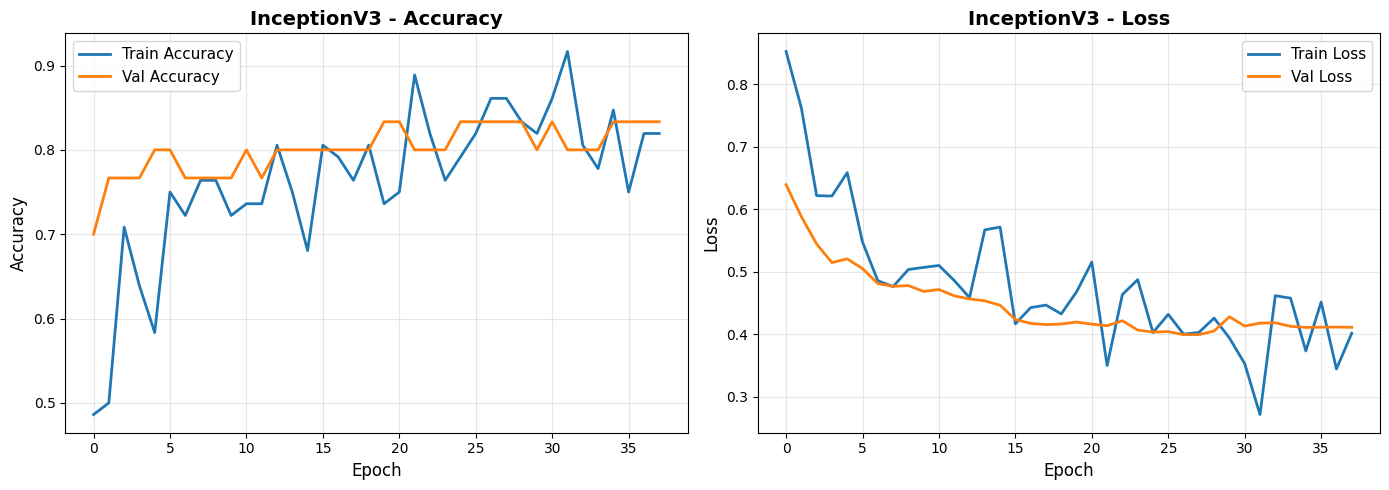

✅ Plot saved: InceptionV3_training_history.png


📊 CLASSIFICATION REPORT - InceptionV3
              precision    recall  f1-score   support

     Healthy     0.7778    0.9333    0.8485        15
   Parkinson     0.9167    0.7333    0.8148        15

    accuracy                         0.8333        30
   macro avg     0.8472    0.8333    0.8316        30
weighted avg     0.8472    0.8333    0.8316        30



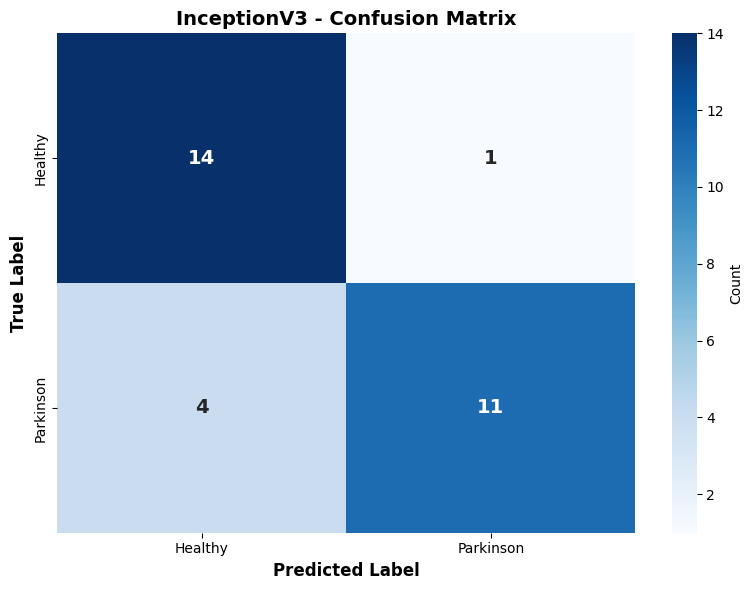

✅ Confusion Matrix saved: InceptionV3_confusion_matrix.png

✅ InceptionV3 TRAINING COMPLETE!
   Test Accuracy: 83.33%
   Test Loss: 0.3996


In [ ]:
print("\n" + "="*60)
print("📌 TRAINING MODEL 2/4: InceptionV3")
print("="*60)

# Create model
base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
model_inception = create_model(base_inception, 'InceptionV3')

# Train
history_inception = model_inception.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks('InceptionV3'),
    verbose=1
)

# Plot training history
plot_training_history(history_inception, 'InceptionV3')

# Evaluate and get results
eval_results_inception = evaluate_model(model_inception, 'InceptionV3')

# Store results
results['InceptionV3'] = {
    'history': history_inception,
    'test_acc': eval_results_inception['test_acc'],
    'test_loss': eval_results_inception['test_loss'],
    'model': model_inception,
    'eval': eval_results_inception
}

print(f"\n{'='*60}")
print(f"✅ InceptionV3 TRAINING COMPLETE!")
print(f"   Test Accuracy: {eval_results_inception['test_acc']*100:.2f}%")
print(f"   Test Loss: {eval_results_inception['test_loss']:.4f}")
print(f"{'='*60}")


### 4.3. ResNet50


📌 TRAINING MODEL 3/4: ResNet50

✅ ResNet50 created!
   Total params: 24,112,513
   Trainable params: 524,801
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5449 - loss: 0.7071
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to ResNet50_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.5374 - loss: 0.7140 - val_accuracy: 0.5000 - val_loss: 0.7100 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.5247 - loss: 0.7607
Epoch 2: val_accuracy improved from 0.50000 to 0.56667, saving model to ResNet50_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 558ms/step - accuracy: 0.5229 - loss: 0.7597 - val_accuracy: 0.5667 - val_loss: 0.6877 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.5605 - loss: 0.7059
Epoch 3: val_accuracy did not improve from 0.56667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 0.5597 - loss: 0.7058 - val_accuracy: 0.5000 - val_loss: 0.6915 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.3705 - loss: 0.8002
Epoch 4: val_accuracy did not improve from 0.56667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.3782 - loss: 0.7954 - val_accuracy: 0.5000 - val_loss: 0.6922 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4691 - loss: 0.7786
Epoch 5: val_accuracy improved from 0.56667 to 0.60000, saving model to ResNet50_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.4650 - loss: 0.7799 - val_accuracy: 0.6000 - val_loss: 0.6871 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.6093 - loss: 0.6612
Epoch 6: val_accuracy did not improve from 0.60000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 0.6004 - loss: 0.6710 - val_accuracy: 0.5333 - val_loss: 0.6872 - learning_rate: 1.0000e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.4082 - loss: 0.7063
Epoch 7: val_accuracy did not improve from 0.60000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.4166 - loss: 0.7102 - val_accuracy: 0.5667 - val_loss: 0.6872 - learning_rate: 1.0000e-04
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.5197 - loss: 0.7066
Epoch 8: val_accuracy did not improve from 0.60000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.5188 - loss: 0.7080 - val_accuracy: 0.5000 - val_loss: 0.6875 - learning_rate: 1.0000e-04
Epoch 9/50
5/5 ━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.4588 - loss: 0.7893 - val_accuracy: 0.6333 - val_loss: 0.6856 - learning_rate: 1.0000e-04
Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.6087 - loss: 0.6918
Epoch 13: val_accuracy did not improve from 0.63333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 354ms/step - accuracy: 0.6091 - loss: 0.6960 - val_accuracy: 0.6333 - val_loss: 0.6856 - learning_rate: 1.0000e-04
Epoch 14/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.4654 - loss: 0.7434
Epoch 14: val_accuracy did not improve from 0.63333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.4711 - loss: 0.7392 - val_accuracy: 0.5333 - val_loss: 0.6863 - learning_rate: 1.0000e-04
Epoch 15/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.5224 - loss: 0.6782
Epoch 15: val_accuracy did not improve from 0.63333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step - accuracy: 0.5256 - loss: 0.6822 - val_accuracy: 0.6000 - val_loss: 0.6849 - learning_rate: 1.0000e-04
Epoch 16/50
5/5 ━

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 466ms/step - accuracy: 0.4604 - loss: 0.8217 - val_accuracy: 0.7000 - val_loss: 0.6822 - learning_rate: 1.0000e-04
Epoch 20/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.4581 - loss: 0.7270
Epoch 20: val_accuracy did not improve from 0.70000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.4581 - loss: 0.7274 - val_accuracy: 0.6667 - val_loss: 0.6817 - learning_rate: 1.0000e-04
Epoch 21/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5175 - loss: 0.7794
Epoch 21: val_accuracy did not improve from 0.70000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.5122 - loss: 0.7833 - val_accuracy: 0.6333 - val_loss: 0.6815 - learning_rate: 1.0000e-04
Epoch 22/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.4997 - loss: 0.7430
Epoch 22: val_accuracy did not improve from 0.70000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.5020 - loss: 0.7416 - val_accuracy: 0.5000 - val_loss: 0.6830 - learning_rate: 1.0000e-04
Epoch 23/50
5/5 ━

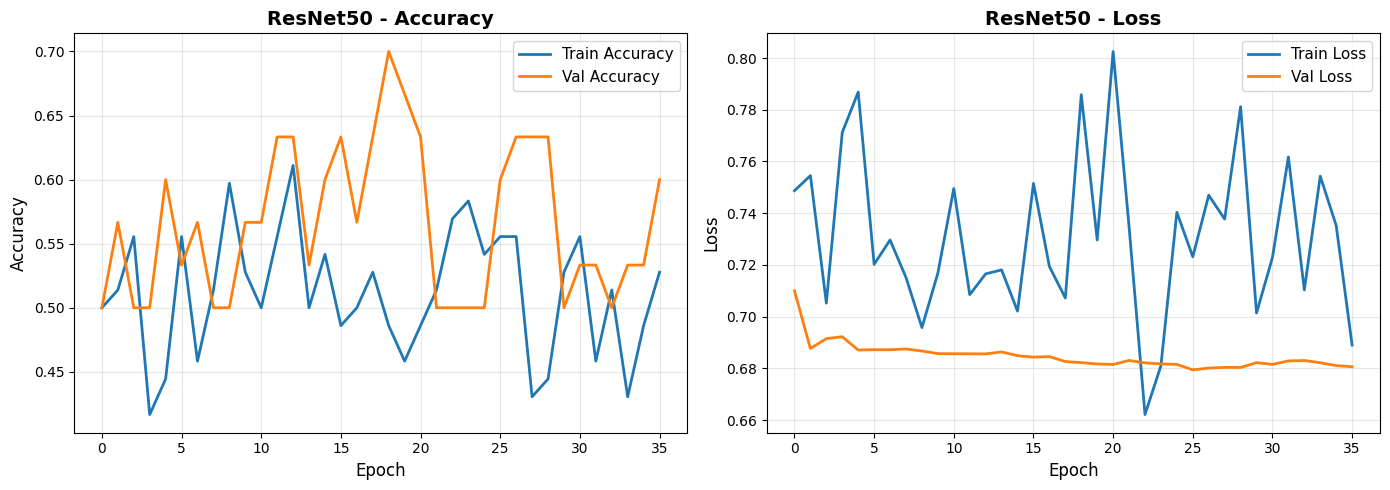

✅ Plot saved: ResNet50_training_history.png




📊 CLASSIFICATION REPORT - ResNet50
              precision    recall  f1-score   support

     Healthy     0.6364    0.4667    0.5385        15
   Parkinson     0.5789    0.7333    0.6471        15

    accuracy                         0.6000        30
   macro avg     0.6077    0.6000    0.5928        30
weighted avg     0.6077    0.6000    0.5928        30



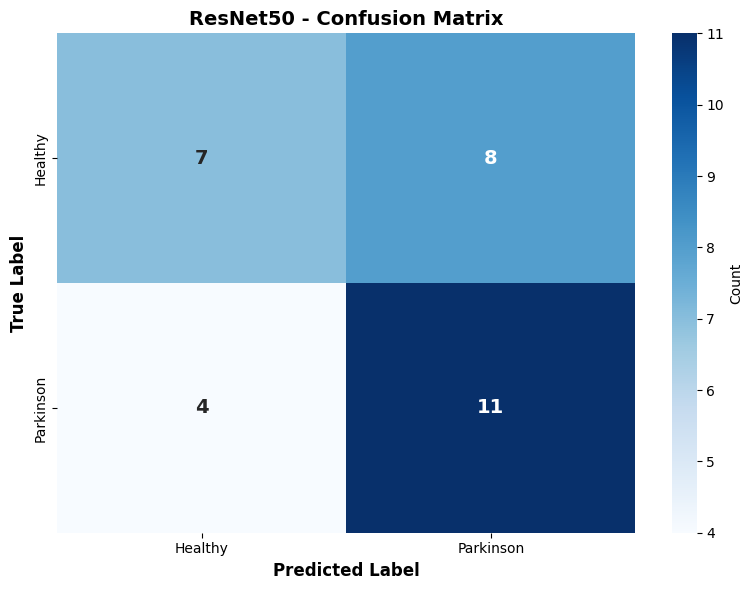

✅ Confusion Matrix saved: ResNet50_confusion_matrix.png

✅ ResNet50 TRAINING COMPLETE!
   Test Accuracy: 60.00%
   Test Loss: 0.6794


In [ ]:
print("\n" + "="*60)
print("📌 TRAINING MODEL 3/4: ResNet50")
print("="*60)

# Create model
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
model_resnet = create_model(base_resnet, 'ResNet50')

# Train
history_resnet = model_resnet.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks('ResNet50'),
    verbose=1
)

# Plot training history
plot_training_history(history_resnet, 'ResNet50')

# Evaluate and get results
eval_results_resnet = evaluate_model(model_resnet, 'ResNet50')

# Store results
results['ResNet50'] = {
    'history': history_resnet,
    'test_acc': eval_results_resnet['test_acc'],
    'test_loss': eval_results_resnet['test_loss'],
    'model': model_resnet,
    'eval': eval_results_resnet
}

print(f"\n{'='*60}")
print(f"✅ ResNet50 TRAINING COMPLETE!")
print(f"   Test Accuracy: {eval_results_resnet['test_acc']*100:.2f}%")
print(f"   Test Loss: {eval_results_resnet['test_loss']:.4f}")
print(f"{'='*60}")


### 4.4. DenseNet169


📌 TRAINING MODEL 4/4: DenseNet169

✅ DenseNet169 created!
   Total params: 13,069,377
   Trainable params: 426,497
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5583 - loss: 0.7986   
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to DenseNet169_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 90s 13s/step - accuracy: 0.5556 - loss: 0.7948 - val_accuracy: 0.6667 - val_loss: 0.6396 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5385 - loss: 0.8450
Epoch 2: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 0.5391 - loss: 0.8394 - val_accuracy: 0.6333 - val_loss: 0.6227 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.4504 - loss: 0.8187
Epoch 3: val_accuracy improved from 0.66667 to 0.80000, saving model to DenseNet169_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 662ms/step - accuracy: 0.4540 - loss: 0.8121 - val_accuracy: 0.8000 - val_loss: 0.5689 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.5433 - loss: 0.6747
Epoch 4: val_accuracy improved from 0.80000 to 0.86667, saving model to DenseNet169_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 661ms/step - accuracy: 0.5453 - loss: 0.6715 - val_accuracy: 0.8667 - val_loss: 0.5249 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.6418 - loss: 0.6037
Epoch 5: val_accuracy did not improve from 0.86667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.6343 - loss: 0.6150 - val_accuracy: 0.8333 - val_loss: 0.5000 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6899 - loss: 0.5890
Epoch 6: val_accuracy did not improve from 0.86667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 571ms/step - accuracy: 0.6907 - loss: 0.5888 - val_accuracy: 0.8333 - val_loss: 0.4818 - learning_rate: 1.0000e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6638 - loss: 0.5999
Epoch 7: val_accuracy did not improve from 0.86667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step - accuracy: 0.6619 - loss: 0.6004 - val_accuracy: 0.8000 - val_loss: 0.4706 - learning_rate: 1.0000e-04
Epoch 8/50
5/5 ━━━━━━━━

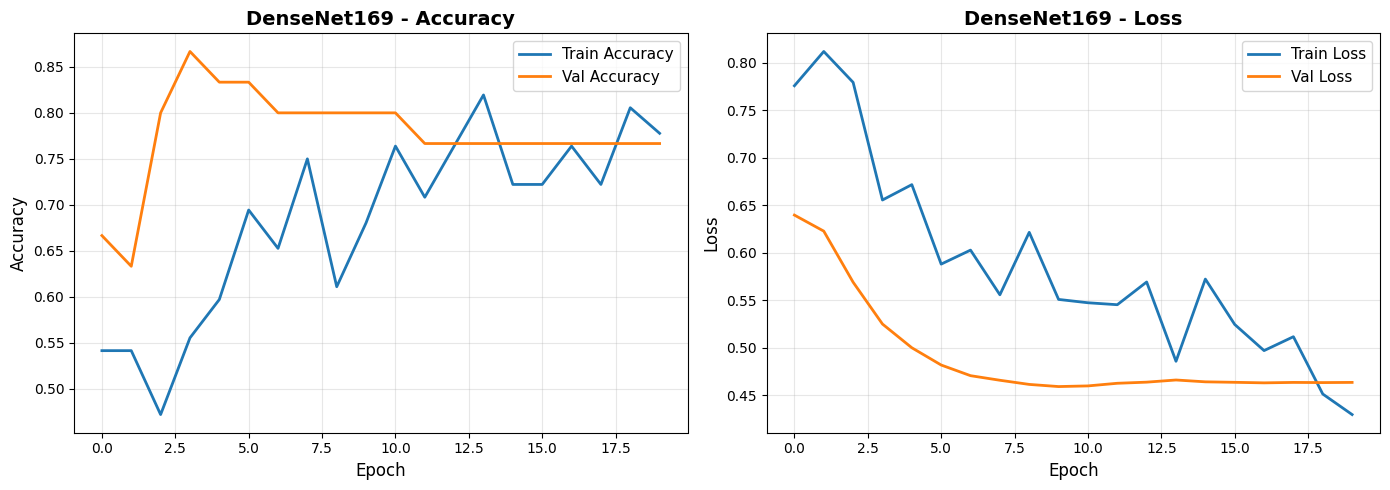

✅ Plot saved: DenseNet169_training_history.png


📊 CLASSIFICATION REPORT - DenseNet169
              precision    recall  f1-score   support

     Healthy     0.7647    0.8667    0.8125        15
   Parkinson     0.8462    0.7333    0.7857        15

    accuracy                         0.8000        30
   macro avg     0.8054    0.8000    0.7991        30
weighted avg     0.8054    0.8000    0.7991        30



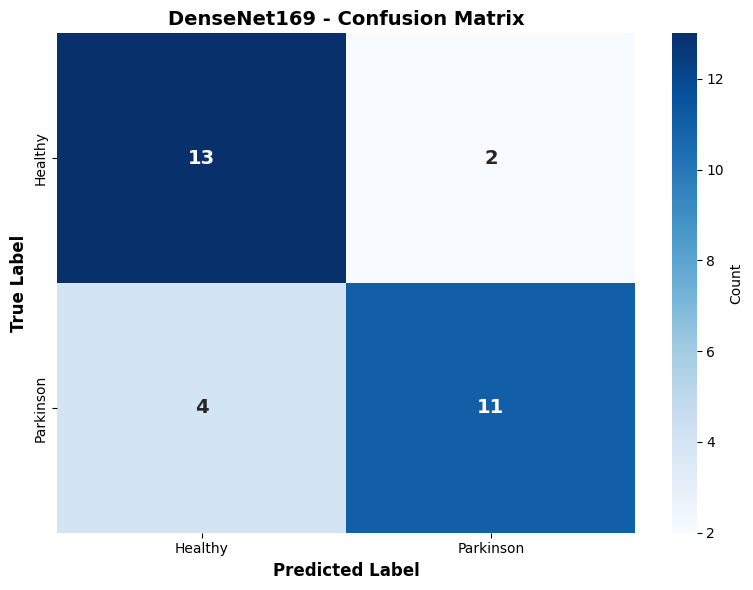

✅ Confusion Matrix saved: DenseNet169_confusion_matrix.png

✅ DenseNet169 TRAINING COMPLETE!
   Test Accuracy: 80.00%
   Test Loss: 0.4591


In [ ]:
print("\n" + "="*60)
print("📌 TRAINING MODEL 4/4: DenseNet169")
print("="*60)

# Create model
base_densenet = DenseNet169(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
model_densenet = create_model(base_densenet, 'DenseNet169')

# Train
history_densenet = model_densenet.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks('DenseNet169'),
    verbose=1
)

# Plot training history
plot_training_history(history_densenet, 'DenseNet169')

# Evaluate and get results
eval_results_densenet = evaluate_model(model_densenet, 'DenseNet169')

# Store results
results['DenseNet169'] = {
    'history': history_densenet,
    'test_acc': eval_results_densenet['test_acc'],
    'test_loss': eval_results_densenet['test_loss'],
    'model': model_densenet,
    'eval': eval_results_densenet
}

print(f"\n{'='*60}")
print(f"✅ DenseNet169 TRAINING COMPLETE!")
print(f"   Test Accuracy: {eval_results_densenet['test_acc']*100:.2f}%")
print(f"   Test Loss: {eval_results_densenet['test_loss']:.4f}")
print(f"{'='*60}")

---
## 📈 BƯỚC 5: VISUALIZE RESULTS

In [ ]:
# Summary table
print("\n" + "="*60)
print("📊 TRAINING RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<15} {'Test Accuracy':<15} {'Best Epoch':<15}")
print("-"*60)

for model_name, data in results.items():
    best_epoch = np.argmax(data['history'].history['val_accuracy']) + 1
    print(f"{model_name:<15} {data['test_acc']*100:>6.2f}%         {best_epoch:<15}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name} ({results[best_model_name]['test_acc']*100:.2f}%)")
print("="*60)


📊 TRAINING RESULTS SUMMARY
Model           Test Accuracy   Best Epoch     
------------------------------------------------------------
VGG19            80.00%         13             
InceptionV3      83.33%         20             
ResNet50         60.00%         19             
DenseNet169      80.00%         4              

🏆 BEST MODEL: InceptionV3 (83.33%)


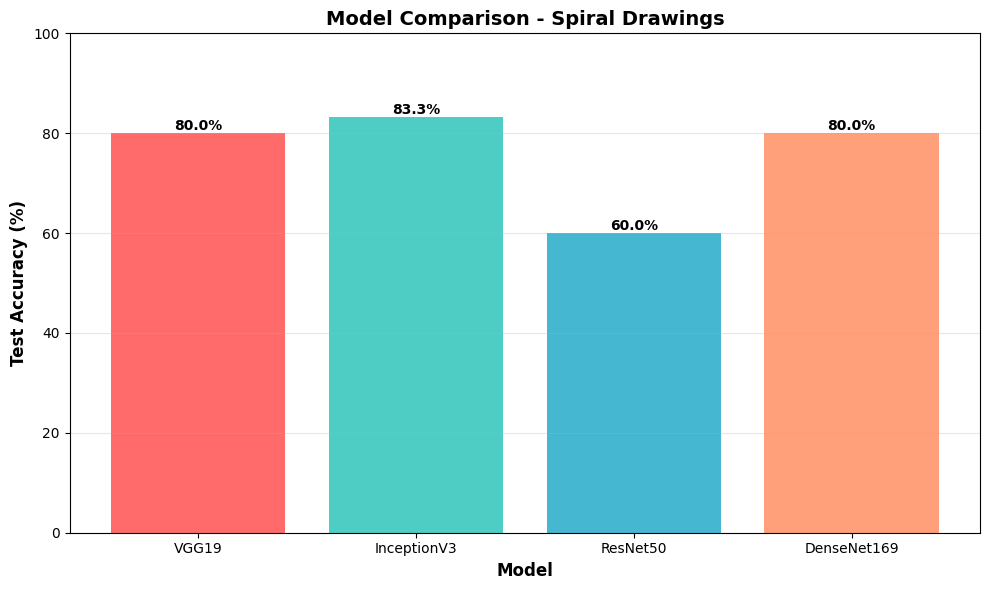

✅ Comparison plot saved: model_comparison.png


In [ ]:
# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
accuracies = [results[m]['test_acc'] * 100 for m in model_names]

bars = ax.bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Spiral Drawings', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison plot saved: model_comparison.png")

BƯỚC 7: LƯU MODELS

In [ ]:
# Save best model to Google Drive
save_path = '/content/drive/MyDrive/Parkinson_Models'  # Thay đổi nếu cần

# Create directory if not exists
os.makedirs(save_path, exist_ok=True)

print("💾 Saving models to Google Drive...\n")

for model_name, data in results.items():
    model_file = os.path.join(save_path, f"{model_name}_spiral.h5")
    data['model'].save(model_file)
    print(f"✅ Saved: {model_file}")

print("\n✅ All models saved to Google Drive!")

💾 Saving models to Google Drive...



✅ Saved: /content/drive/MyDrive/Parkinson_Models/VGG19_spiral.h5


✅ Saved: /content/drive/MyDrive/Parkinson_Models/InceptionV3_spiral.h5


✅ Saved: /content/drive/MyDrive/Parkinson_Models/ResNet50_spiral.h5
✅ Saved: /content/drive/MyDrive/Parkinson_Models/DenseNet169_spiral.h5

✅ All models saved to Google Drive!
